##  **_Analisis Sentimen Game The Ragnarok_** ##

### **Install & Import Dependencies** ###

In [18]:
# Install required libraries (if not installed)
!pip install pandas google-play-scraper

# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Extract Package Name from Google Play URL** ###

In [19]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.ggt.tr.google&pcampaignid=merch_published_cluster_promotion_battlestar_top_picks&hl=id"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.ggt.tr.google


### **Fetch Google Play Reviews** ###

In [20]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: Indonesia
    country='id',  # Country: Indonesian
    count= 200,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,502e6650-c390-4e38-8c1a-e4761bbe117a,abduh mi,https://play-lh.googleusercontent.com/a-/ALV-U...,"tolong lebih ramah pada gamer indo, kartu hara...",5,1,122,2026-04-21 16:20:38,NaN,NaT,122
1,92286c44-9194-466d-b9de-ef173e6329ad,Heri Arbi,https://play-lh.googleusercontent.com/a/ACg8oc...,Download Mayan Besar Filenya. Giliran Dimainka...,3,0,NaN,2026-04-15 10:21:39,NaN,NaT,NaN
2,05107345-e992-4cfc-8dbd-d3600c0d2c21,Herry Heo,https://play-lh.googleusercontent.com/a/ACg8oc...,susah membuat nama karakter,1,0,122,2026-04-06 07:53:55,NaN,NaT,122
3,54b10fa2-fd0d-4ea9-9a6c-b6e8656d25ce,Ahmad Waldan,https://play-lh.googleusercontent.com/a/ACg8oc...,pihak Ragnarok sepertinya sengaja bikin gamepl...,1,0,116.0,2026-03-20 09:09:27,NaN,NaT,116.0
4,5daf6773-b9d4-4712-8e0c-e64d0f6015f6,Fazeilly Husseini Agasya,https://play-lh.googleusercontent.com/a-/ALV-U...,"kapan job Dancer/Bard, Alchemist, dan Rogue ri...",1,1,122,2026-03-17 13:27:45,NaN,NaT,122
...,...,...,...,...,...,...,...,...,...,...,...
195,902f906b-18c7-4964-b32c-8d51fad47e27,Dadan 19,https://play-lh.googleusercontent.com/a-/ALV-U...,Another Ragnarok frontier,1,0,NaN,2024-11-24 10:16:38,NaN,NaT,NaN
196,eb541cdf-c10f-46a3-bc57-cce8a14a3a5b,Aziz Bikahan,https://play-lh.googleusercontent.com/a-/ALV-U...,Game tolol,1,0,NaN,2024-11-24 09:47:42,NaN,NaT,NaN
197,046c6004-4b7b-47e7-b512-c67cb592326e,Medi Kaneki,https://play-lh.googleusercontent.com/a/ACg8oc...,Game y udah bagus cuma suka force close,5,0,116.0,2024-11-24 06:08:02,NaN,NaT,116.0
198,20d77918-2cb4-4711-92c1-373313d5aee5,Denny Pentem,https://play-lh.googleusercontent.com/a/ACg8oc...,Game bug,1,0,116.0,2024-11-24 02:15:54,NaN,NaT,116.0


### **Filter Required Columns** ###

In [21]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,502e6650-c390-4e38-8c1a-e4761bbe117a,"tolong lebih ramah pada gamer indo, kartu hara...",5
1,92286c44-9194-466d-b9de-ef173e6329ad,Download Mayan Besar Filenya. Giliran Dimainka...,3
2,05107345-e992-4cfc-8dbd-d3600c0d2c21,susah membuat nama karakter,1
3,54b10fa2-fd0d-4ea9-9a6c-b6e8656d25ce,pihak Ragnarok sepertinya sengaja bikin gamepl...,1
4,5daf6773-b9d4-4712-8e0c-e64d0f6015f6,"kapan job Dancer/Bard, Alchemist, dan Rogue ri...",1
...,...,...,...
195,902f906b-18c7-4964-b32c-8d51fad47e27,Another Ragnarok frontier,1
196,eb541cdf-c10f-46a3-bc57-cce8a14a3a5b,Game tolol,1
197,046c6004-4b7b-47e7-b512-c67cb592326e,Game y udah bagus cuma suka force close,5
198,20d77918-2cb4-4711-92c1-373313d5aee5,Game bug,1


### **Sentiment Google PlayStore** ###

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Indonesia
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('indonesian'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

     # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marcella\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Marcella\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Marcella\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,content,cleaned_text
0,"tolong lebih ramah pada gamer indo, kartu hara...",tolong ramah gamer indo kartu harap gratis
1,Download Mayan Besar Filenya. Giliran Dimainka...,download mayan filenya giliran dimainkan zonk ...
2,susah membuat nama karakter,susah nama karakter
3,pihak Ragnarok sepertinya sengaja bikin gamepl...,ragnarok sengaja bikin gameplay sebagus koneks...
4,"kapan job Dancer/Bard, Alchemist, dan Rogue ri...",job dancerbard alchemist rogue rilis rilis gan...
5,padahal sinyal bagus baru mau nyoba saja gak m...,sinyal bagus nyoba gak maju maju loading nya p...
6,Game saya kuliah dulu waktu main di warnet.Bag...,game kuliah main warnetbagus kuota hemat
7,cuma bisa masuk pas memilih character pas masu...,masuk pa memilih character pa masuk game muncu...
8,game nya jelek masa login failed trus gmana ma...,game nya jelek login failed trus gmana maju ni...
9,tipuan fkr geng beng,tipuan fkr geng beng


### **Membuat World Cloud** ###

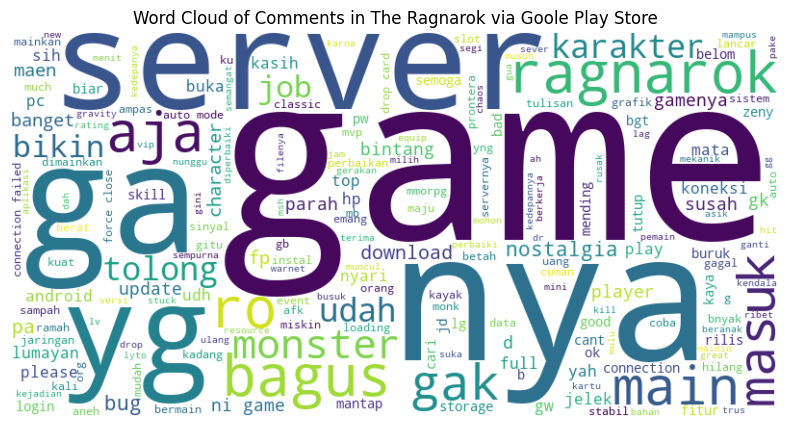

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in The Ragnarok via Goole Play Store")
plt.show()

### **Mencari Frekuensi yang Paling Sering Muncul** ###

          Word  Frequency
45        game         84
41         nya         41
70          ga         29
24      server         26
222         yg         20
36       bagus         15
18    ragnarok         15
103        aja         14
71          ro         14
47        main         13
51       masuk         12
293    monster         11
38         gak         11
0       tolong         10
17    karakter         10
138       udah         10
27         job          9
20       bikin          9
265  nostalgia          9
496        bug          9


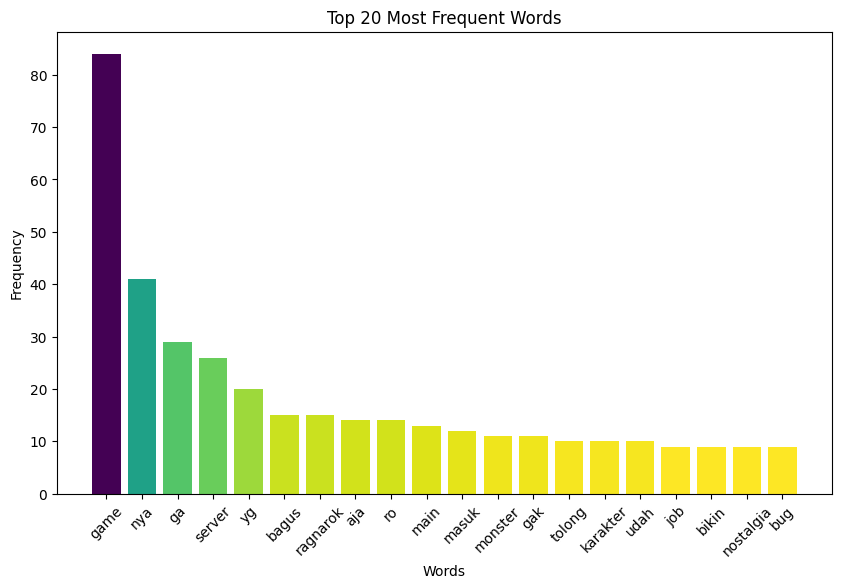

In [25]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(200, 915)


In [27]:

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (200, 914)
Dimensi target y: (200,)


In [28]:

from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 160
Jumlah data testing: 40


### **Model Logistic Regression** ###

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression(class_weight='balanced')

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 70.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.84      0.81        31
    Positive       0.29      0.22      0.25         9

    accuracy                           0.70        40
   macro avg       0.54      0.53      0.53        40
weighted avg       0.67      0.70      0.69        40



In [38]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "game bagus"
test_sentence_2 = "game nya jelek"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'game bagus'
Prediksi: Positive

Review: 'game nya jelek'
Prediksi: Negative


### **Prediksi Data** ###

In [31]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,"tolong lebih ramah pada gamer indo, kartu hara...",5,Negative
1,Download Mayan Besar Filenya. Giliran Dimainka...,3,Negative
2,susah membuat nama karakter,1,Negative
3,pihak Ragnarok sepertinya sengaja bikin gamepl...,1,Negative
4,"kapan job Dancer/Bard, Alchemist, dan Rogue ri...",1,Negative


### **Visualisasi Distribusi Prediksi Sentimen** ###

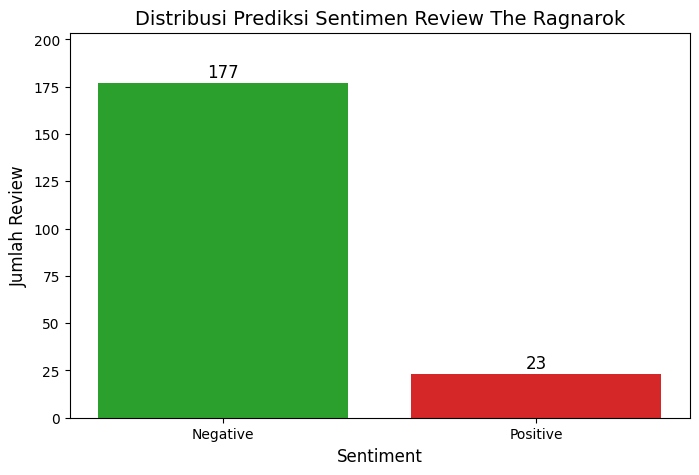

In [40]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ca02c', '#d62728']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review The Ragnarok', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()
     